# Customer Analysis for Retail

### 📚 **Importing Required Libraries for Analysis**


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
%matplotlib inline

### 🗃️ **Importing Required Datasets**

In [12]:
customers = pd.read_csv('customer.csv')
transactions = pd.read_csv('transactions.csv')
prod_cat_info = pd.read_csv('prod_cat_info.csv')

### 🧾 **Finalized Customer Data Table**

In [14]:
cust_trans = pd.merge(customers,transactions,how='inner',left_on='customer_Id',right_on='cust_id')
customer_final = pd.merge(cust_trans,prod_cat_info,how='left',left_on=['prod_cat_code','prod_subcat_code'],right_on=['prod_cat_code','prod_sub_cat_code'])


#### 🧹 **Checking Null Values and Taking Required Action**

In [16]:
# Analyzing the count of Null Values
(len(customer_final) - customer_final.count())

# Dropping the NULL Values as it is less than 5%

customer_final.dropna(axis=0,inplace = True)

#### 🧾 **Column Names and Their Corresponding Data Types**

In [18]:
customer_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23036 entries, 0 to 23052
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_Id        23036 non-null  int64  
 1   DOB                23036 non-null  object 
 2   Gender             23036 non-null  object 
 3   city_code          23036 non-null  float64
 4   transaction_id     23036 non-null  int64  
 5   cust_id            23036 non-null  int64  
 6   tran_date          23036 non-null  object 
 7   prod_subcat_code   23036 non-null  int64  
 8   prod_cat_code      23036 non-null  int64  
 9   Qty                23036 non-null  int64  
 10  Rate               23036 non-null  int64  
 11  Tax                23036 non-null  float64
 12  total_amt          23036 non-null  float64
 13  Store_type         23036 non-null  object 
 14  prod_cat           23036 non-null  object 
 15  prod_sub_cat_code  23036 non-null  int64  
 16  prod_subcat        23036 no

#### 🔝 **Top 5 Observations**

In [20]:
customer_final.head()

,customer_Id,DOB,Gender,city_code,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,prod_cat,prod_sub_cat_code,prod_subcat
0,268408,02-01-1970,M,4.0,87243835584,268408,13-01-2014,7,5,5,187,98.175,1033.175,TeleShop,Books,7,Fiction
1,268408,02-01-1970,M,4.0,16197868036,268408,16-12-2013,1,4,-5,-210,110.250,-1160.250,Flagship store,Bags,1,Mens
2,268408,02-01-1970,M,4.0,16197868036,268408,12/12/2013,1,4,5,210,110.250,1160.250,Flagship store,Bags,1,Mens
3,268408,02-01-1970,M,4.0,28810141075,268408,2/9/2013,10,6,2,813,170.730,1796.730,TeleShop,Home and kitchen,10,Kitchen
4,268408,02-01-1970,M,4.0,64633435931,268408,6/5/2013,4,2,3,312,98.280,1034.280,Flagship store,Footwear,4,Kids


#### 📐 **Five Point Summary for Continuous Variables**

In [22]:
pd.set_option('display.float_format', '{:.2f}'.format)
customer_final.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
customer_Id,23036.00,271023.34,2431.47,266783.00,268936.00,270981.00,273115.25,275265.00
city_code,23036.00,5.48,2.86,1.00,3.00,5.00,8.00,10.00
transaction_id,23036.00,50069603815.48,28985829331.06,3268991.00,24922299300.50,50089415811.00,75326317773.50,99987549630.00
cust_id,23036.00,271023.34,2431.47,266783.00,268936.00,270981.00,273115.25,275265.00
prod_subcat_code,23036.00,6.15,3.73,1.00,3.00,5.00,10.00,12.00
prod_cat_code,23036.00,3.76,1.68,1.00,2.00,4.00,5.00,6.00
Qty,23036.00,2.43,2.27,-5.00,1.00,3.00,4.00,5.00
Rate,23036.00,636.39,622.51,-1499.00,312.00,710.00,1109.00,1500.00
Tax,23036.00,248.69,187.19,7.35,98.28,199.08,365.77,787.50
total_amt,23036.00,2107.32,2507.88,-8270.92,762.45,1754.74,3569.15,8287.50


#### 📊 **Frequency Bars for All Categorical Variables**

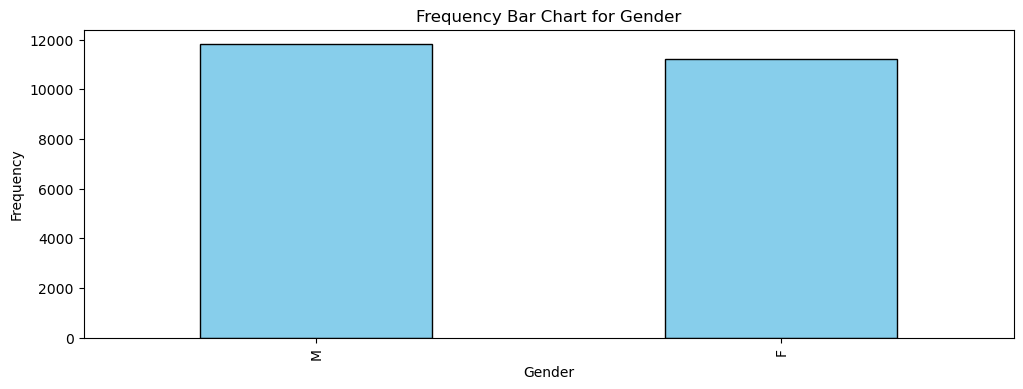

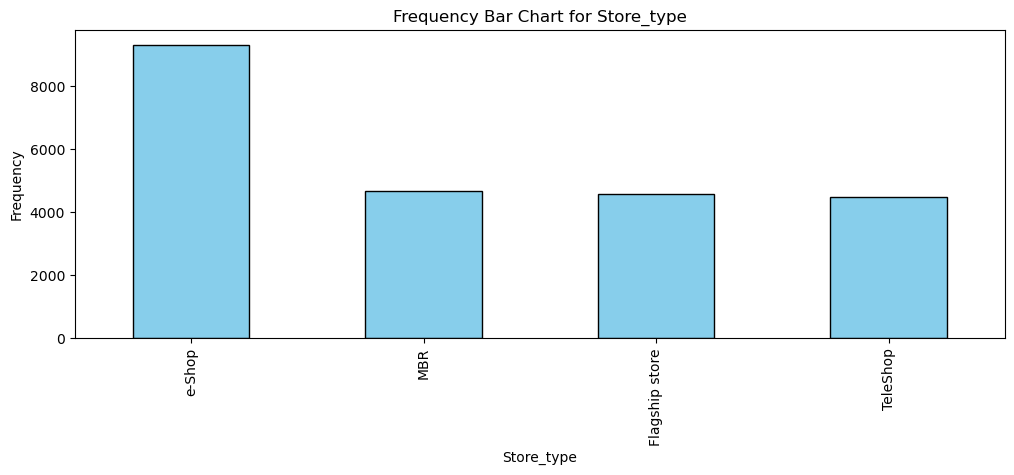

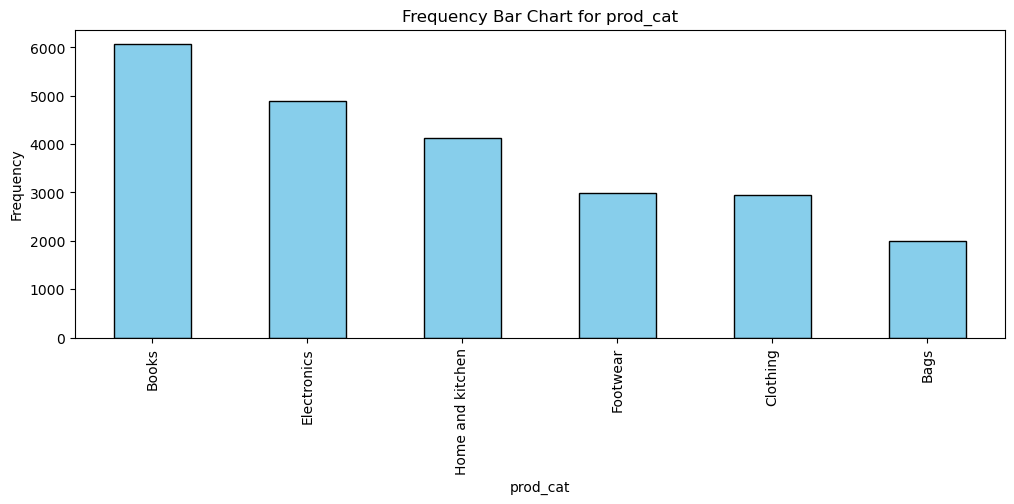

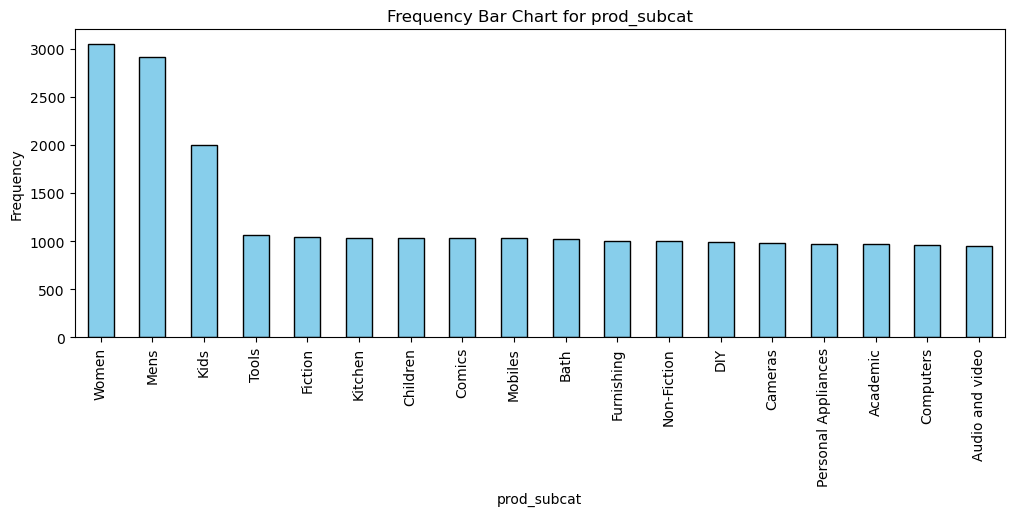

In [24]:
categorical = customer_final.select_dtypes('object').drop(columns=['tran_date','DOB'])

for col in categorical.columns:
    plt.figure(figsize=(12,4))
    categorical[col].value_counts().plot(kind='bar',color='skyblue',edgecolor='black')
    plt.title(f'Frequency Bar Chart for {col}')
    plt.ylabel('Frequency')
    plt.xlabel(col)
    plt.show()

#### 📉 **Histograms for All Continuous Variables**

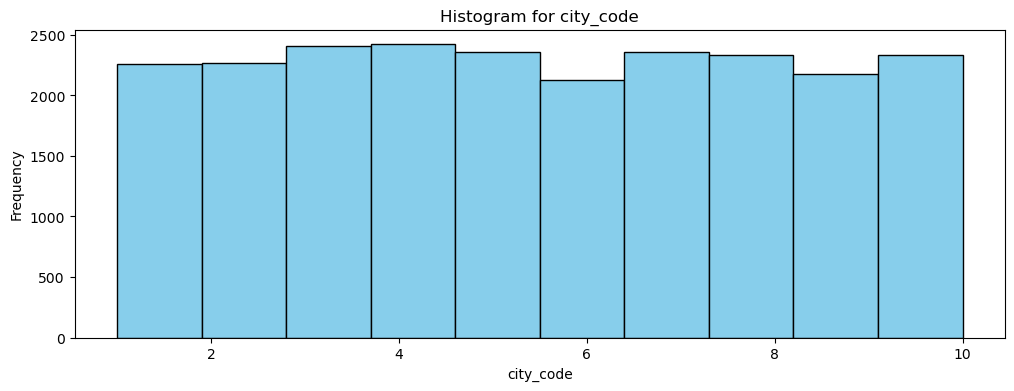

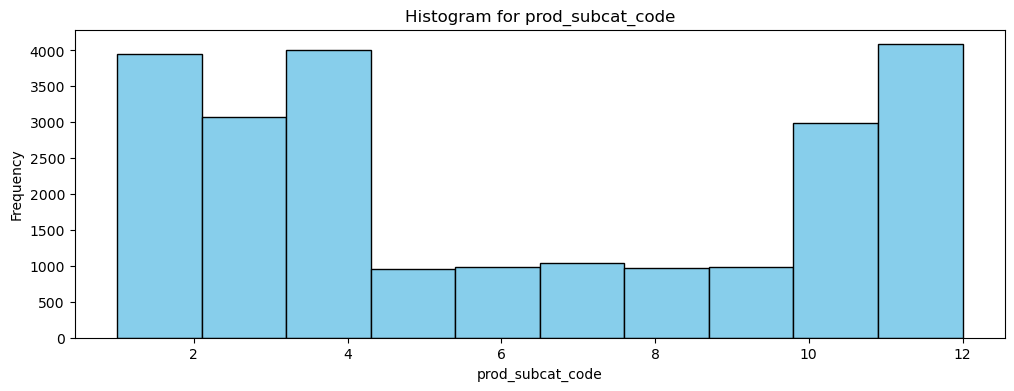

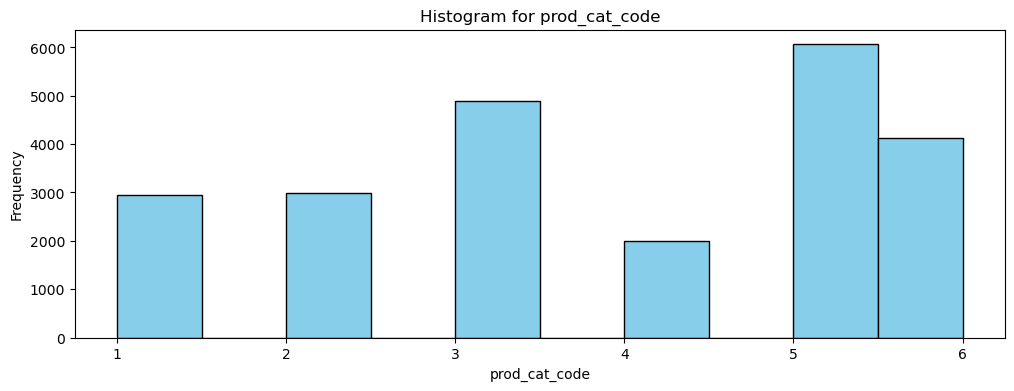

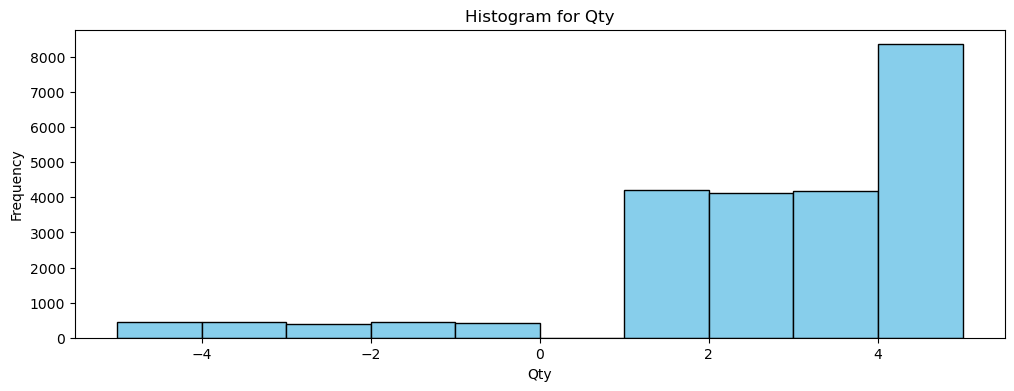

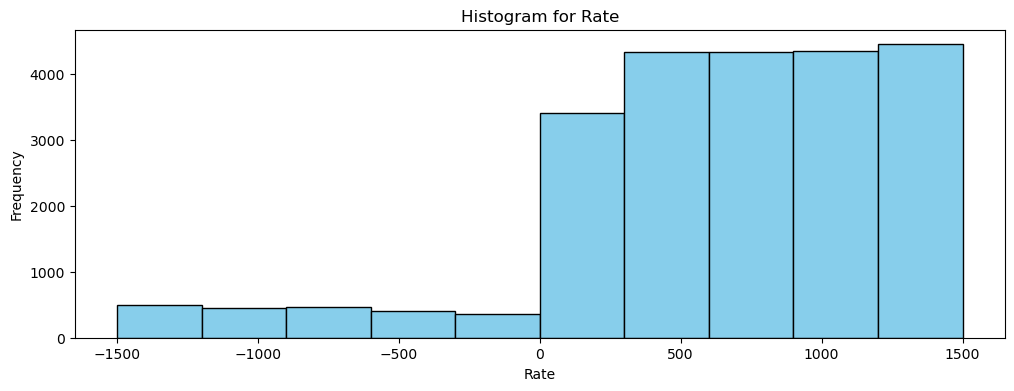

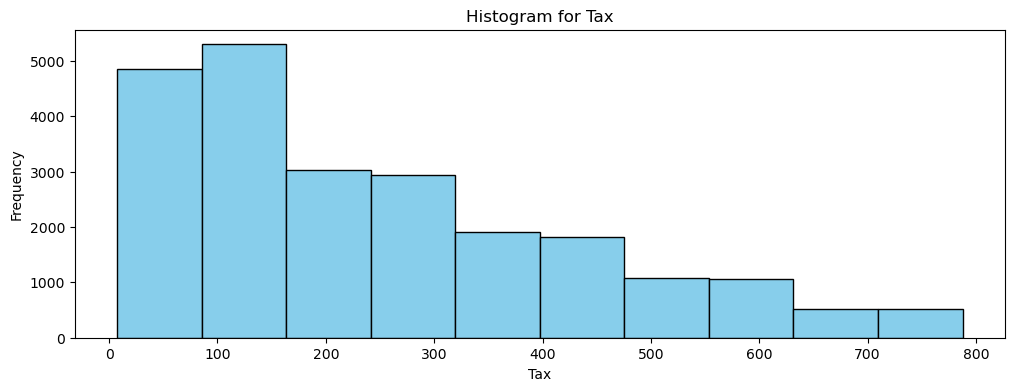

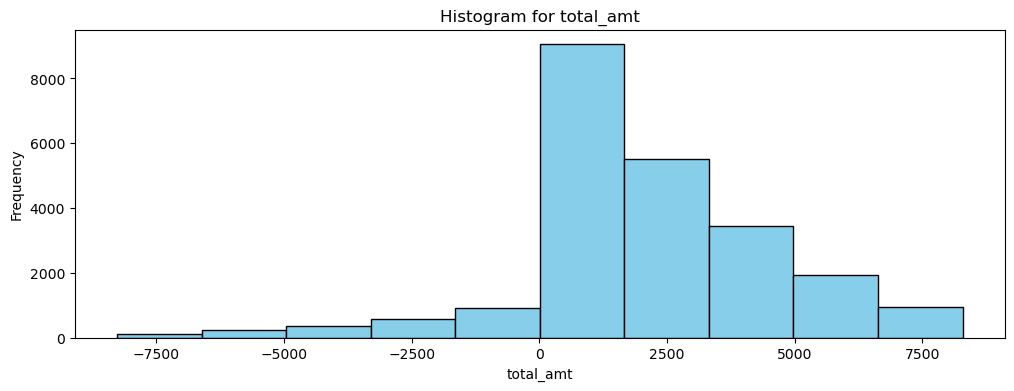

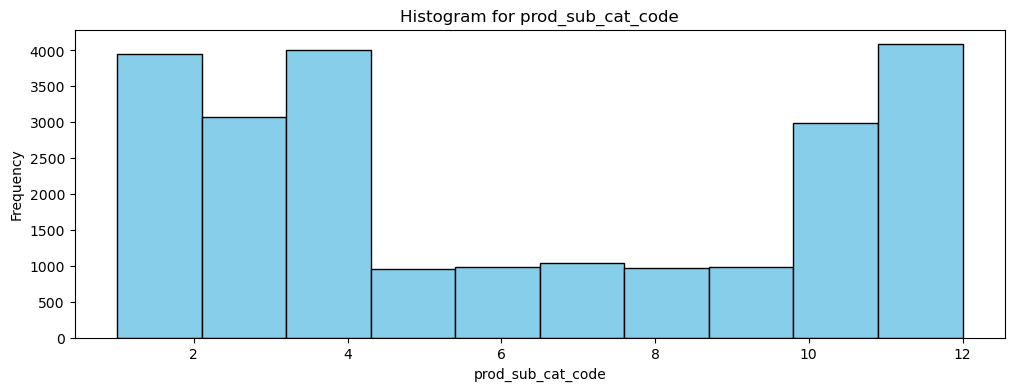

In [26]:
continuous = customer_final.select_dtypes('number').drop(columns=['transaction_id','cust_id','customer_Id'])
continuous

for col in continuous.columns:
    plt.figure(figsize=(12,4))
    continuous[col].plot(kind='hist',bins=10,color='skyblue',edgecolor='black')
    plt.title(f'Histogram for {col}')
    plt.ylabel('Frequency')
    plt.xlabel(col)
    plt.show()

#### 🗓️ **Time Period of the Available Transaction Data**

In [28]:
date1 = pd.to_datetime(customer_final['tran_date'],format = '%d-%m-%Y',errors = 'coerce')
date2 = pd.to_datetime(customer_final['tran_date'],format = '%d/%m/%Y',errors = 'coerce')
customer_final['tran_date'] = date1.combine_first(date2)

start = customer_final['tran_date'].min().strftime(format='%b %Y')
end = customer_final['tran_date'].max().strftime(format='%b %Y')

print(f'All the transactions are between {start} and {end}')

All the transactions are between Jan 2011 and Feb 2014


#### 🚫 **Transactions with Negative Total Amount**

In [80]:
customer_final.loc[customer_final.total_amt<0,:].head()

,customer_Id,DOB,Age,Gender,city_code,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,prod_cat,prod_sub_cat_code,prod_subcat
1,268408,1970-01-02,55,M,4,16197868036,268408,2013-12-16,1,4,-5,-210,110.25,-1160.25,Flagship store,Bags,1,Mens
11,269696,1970-01-07,55,F,8,47604927293,269696,2012-04-15,9,3,-4,-735,308.70,-3248.70,MBR,Electronics,9,Cameras
20,270181,1970-01-10,55,F,2,86078338517,270181,2014-01-16,11,5,-2,-1404,294.84,-3102.84,e-Shop,Books,11,Children
27,270181,1970-01-10,55,F,2,82362804856,270181,2012-01-20,2,6,-4,-521,218.82,-2302.82,e-Shop,Home and kitchen,2,Furnishing
30,268073,1970-01-11,55,M,1,33468347680,268073,2013-12-30,3,2,-1,-668,70.14,-738.14,MBR,Footwear,3,Women


#### 🛍️ **Product Categories More Popular Among Female vs. Male Customers**

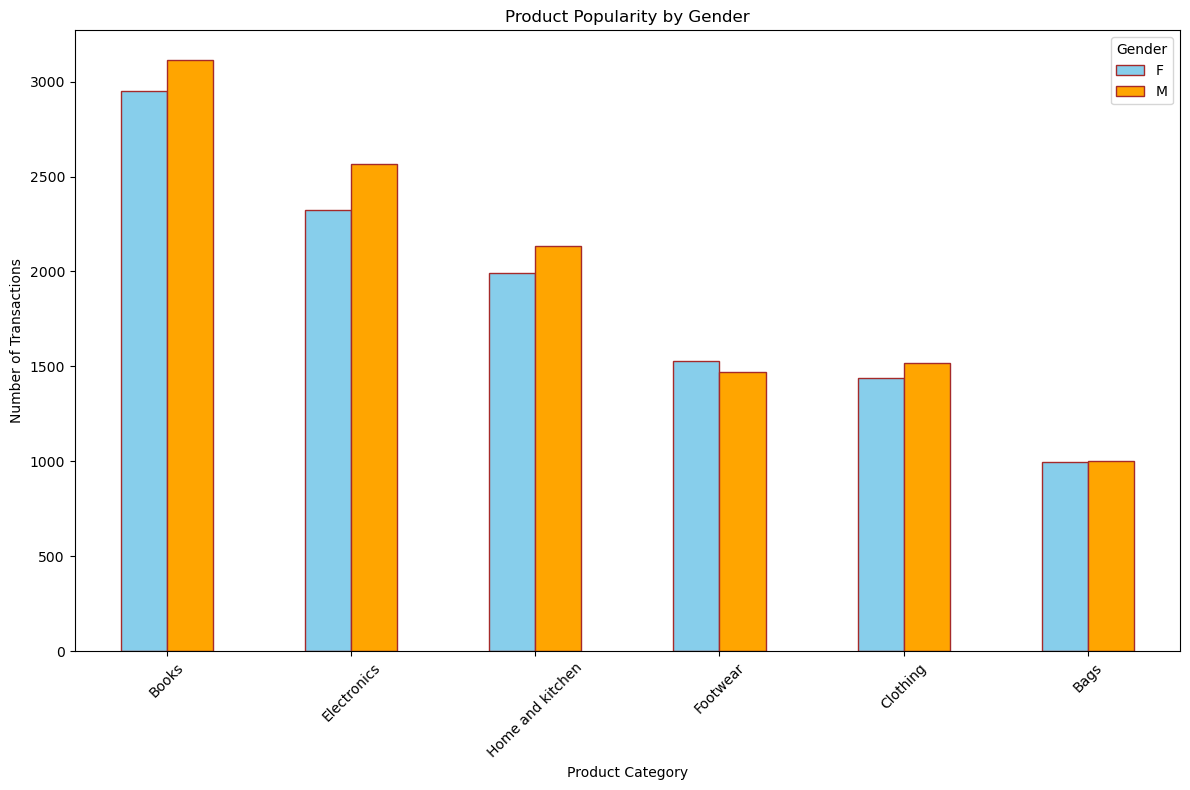

In [32]:
pivot_df = customer_final.pivot_table(index='prod_cat',columns='Gender',aggfunc='size').sort_values(by='F',ascending=False)
pivot_df.plot(kind='bar', figsize=(12,8), title='Product Popularity by Gender', stacked=False, color=['skyblue','orange'], edgecolor='brown')
plt.ylabel('Number of Transactions')
plt.xlabel('Product Category')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

#### **🏙️ City Code with Maximum Customers and Their Percentage**

In [34]:
customer_final.city_code = customer_final.city_code.astype('int')
customer_final.groupby(['city_code'],sort=False)['customer_Id'].count()

df = customer_final.pivot_table(index='city_code',values='customer_Id',aggfunc='count',sort=False).reset_index()
df['customer_Id'] = round(df['customer_Id']/df['customer_Id'].sum() *100,2)

print(f'City Code with maximum customers: {df["city_code"][0]}')
print(f'% of customers: {df["customer_Id"][0]}')

City Code with maximum customers: 4
% of customers: 10.51


#### 🏪 **Store Type Selling Maximum Products by Value and Quantity**

In [36]:
df = customer_final.pivot_table(index=['Store_type'],values=['total_amt','Qty'],aggfunc='sum').sort_values(
    by=['total_amt','Qty'],ascending=[False,False]).reset_index()

print(f'Store Type that sells max products by Quantity: {df.Store_type[0]}')
print(f'Store Type that sells max products by Amount: {df.Store_type[0]}')


Store Type that sells max products by Quantity: e-Shop
Store Type that sells max products by Amount: e-Shop


#### 💵 **Total Amount Earned from "Electronics" and "Clothing" Categories in Flagship Stores**


In [38]:
df = customer_final.loc[(customer_final.Store_type=='Flagship store') & (customer_final['prod_cat'].isin(['Electronics','Clothing'])),:]
round(df.total_amt.sum(),2)
print(f'Total Amount Earned from Electronics and Clothing Categories in Flagship Stores is {round(df.total_amt.sum(),2)}')


Total Amount Earned from Electronics and Clothing Categories in Flagship Stores is 3408936.05


#### 🧍‍♂️ **Total Amount Earned from "Male" Customers in the "Electronics" Category**

In [40]:
tam = round(customer_final.loc[(customer_final['Gender']=='M') & (customer_final['prod_cat']=='Electronics'),:]['total_amt'].sum(),2)
print(f'Total Amount Earned from Male Customers in the Electronics Category is {tam}')

Total Amount Earned from Male Customers in the Electronics Category is 5697629.73


#### 🔢 **Customers with More Than 10 Unique Transactions (Excluding Negative Amounts)**


In [42]:
df = customer_final.loc[customer_final.total_amt>0].pivot_table(index='cust_id',values='transaction_id',aggfunc='nunique').reset_index()
df.loc[df.transaction_id>10]

,cust_id,transaction_id
4,266794,11
2423,270535,11
2603,270803,11
3863,272741,11
4028,273014,11
4811,274227,11


### 🧑‍💼 **Total Amount Spent by Customers Aged 25–35 on "Electronics" and "Books**


In [44]:
customer_final['DOB']=pd.to_datetime(customer_final['DOB'],format='%d-%m-19%y')
customer_final.insert(2,column='Age',value = (pd.Timestamp.now() - customer_final['DOB']).dt.days/365.25)
customer_final['Age'] = customer_final.Age.astype('int')
t = round(customer_final.loc[(customer_final['Age'].between(25,35)) & (customer_final['prod_cat'].isin(['Electronics','Books']))].total_amt.sum(),2)
print(f'Total Amount Spent by Customers Aged 25–35 on Electronics and Books: {t}')

Total Amount Spent by Customers Aged 25–35 on Electronics and Books: 3588457.66


### 📅 **Total Amount Spent by Customers Aged 25–35 Between 1st Jan, 2014 and 1st Mar, 2014**

In [46]:
customer_final['tran_date'] = pd.to_datetime(customer_final['tran_date'])
t = round(customer_final.loc[(customer_final['Age'].between(25,35)) & (customer_final['tran_date'].between('2014-01-01','2014-03-01'))]['total_amt'].sum(),2)
print(f'Total Amount Spent by Customers Aged 25–35 Between 1st Jan, 2014 and 1st Mar, 2014: {t}')


Total Amount Spent by Customers Aged 25–35 Between 1st Jan, 2014 and 1st Mar, 2014: 396706.05


### 📌 **Key Takeaways**

* The dataset covers retail transactions made by customers between January 2011 and February 2014.
* Male customers account for 51% of the total transactions.
* The most preferred store type among customers was the e-Shop.
* Books emerged as the most frequently purchased product category.
* Within product subcategories, the Women subcategory had the highest number of transactions.
* Product returns represent approximately 9% of total transactions.
* Books were popular across both Men's and Women's product segments.
* Bags was the least popular product category.
* The highest number of customers belonged to City Code 4.